# Godot DQN Agent

This notebook runs the training loop, connecting the `DQNAgent` to the Godot environment. It automatically launches Godot in **headless mode** to massively speed up training without rendering graphics.

In [1]:
import asyncio
import websockets
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import subprocess
import os
import time

MODEL_PATH = os.path.abspath(os.path.join(os.getcwd(), "dqn_model.pth"))

# Import our modular DQN components
from dqn_agent import DQNAgent

class GodotEnv:
    def __init__(self, host='127.0.0.1', port=11000):
        self.host = host
        self.port = port
        self.server = None
        self.websocket = None
        self.last_state = []
        self.last_reward = 0.0
        self.last_done = False
        self.last_score = 0.0
        self.response_event = asyncio.Event()

    async def start_server(self):
        try:
            self.server = await websockets.serve(self.handler, self.host, self.port)
        except OSError as e:
            raise RuntimeError(
                f"Failed to bind ws://{self.host}:{self.port} (port already in use?). "
                "Restart the notebook kernel or stop the previous training run."
            ) from e
        print(f"WebSocket server started at ws://{self.host}:{self.port}")

    async def stop_server(self):
        if self.server is not None:
            self.server.close()
            await self.server.wait_closed()
            self.server = None
            print("WebSocket server stopped.")

    async def handler(self, websocket, path=None):
        print("Godot connected!")
        self.websocket = websocket
        try:
            async for message in websocket:
                data = json.loads(message)
                self.last_state = data.get('state', [])
                self.last_reward = data.get('reward', 0.0)
                self.last_done = data.get('done', False)
                self.last_score = data.get('score', 0.0)
                self.response_event.set()
        except websockets.exceptions.ConnectionClosed:
            print("Godot disconnected.")
            self.websocket = None
            self.response_event.set()

    async def step(self, action: int):
        if self.websocket:
            self.response_event.clear()
            await self.websocket.send(json.dumps({"action": action}))
            if await self._wait_for_response():
                return self.last_state, self.last_reward, self.last_done, self.last_score
        return [], 0.0, True, 0.0

    async def reset(self):
        if self.websocket:
            self.response_event.clear()
            await self.websocket.send(json.dumps({"command": "reset"}))
            if await self._wait_for_response():
                return self.last_state
        return []

    async def _wait_for_response(self, timeout: float = 30.0) -> bool:
        try:
            await asyncio.wait_for(self.response_event.wait(), timeout=timeout)
            return True
        except asyncio.TimeoutError:
            print("Timed out waiting for Godot response; closing connection.")
            self.websocket = None
            return False

async def wait_for_godot(env: GodotEnv, timeout: float = 30.0):
    start = time.time()
    while env.websocket is None:
        if time.time() - start > timeout:
            raise RuntimeError(f"Godot did not connect to ws://{env.host}:{env.port} within {timeout:.0f}s. Check the Godot executable path and that the port is free.")
        await asyncio.sleep(0.5)


In [2]:
def plot_metrics(episode_rewards, moving_avg, epsilons, losses):
    clear_output(wait=True)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

    # Reward Plot
    ax1.plot(episode_rewards, alpha=0.3, color='blue', label='Episode Reward')
    ax1.plot(moving_avg, color='red', label='Moving Avg')
    ax1.set_title('Training Rewards')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Reward')
    ax1.legend()

    # Loss Plot
    ax2.plot(losses, color='purple')
    ax2.set_title('Average Loss per Episode')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Loss')

    # Epsilon Plot
    ax3.plot(epsilons, color='orange')
    ax3.set_title('Epsilon Decay')
    ax3.set_xlabel('Episode')
    ax3.set_ylabel('Epsilon')

    plt.tight_layout()
    plt.show()


## Phase 4: Training Loop (Headless)
Running this cell will automatically launch Godot in headless mode and start the training process.

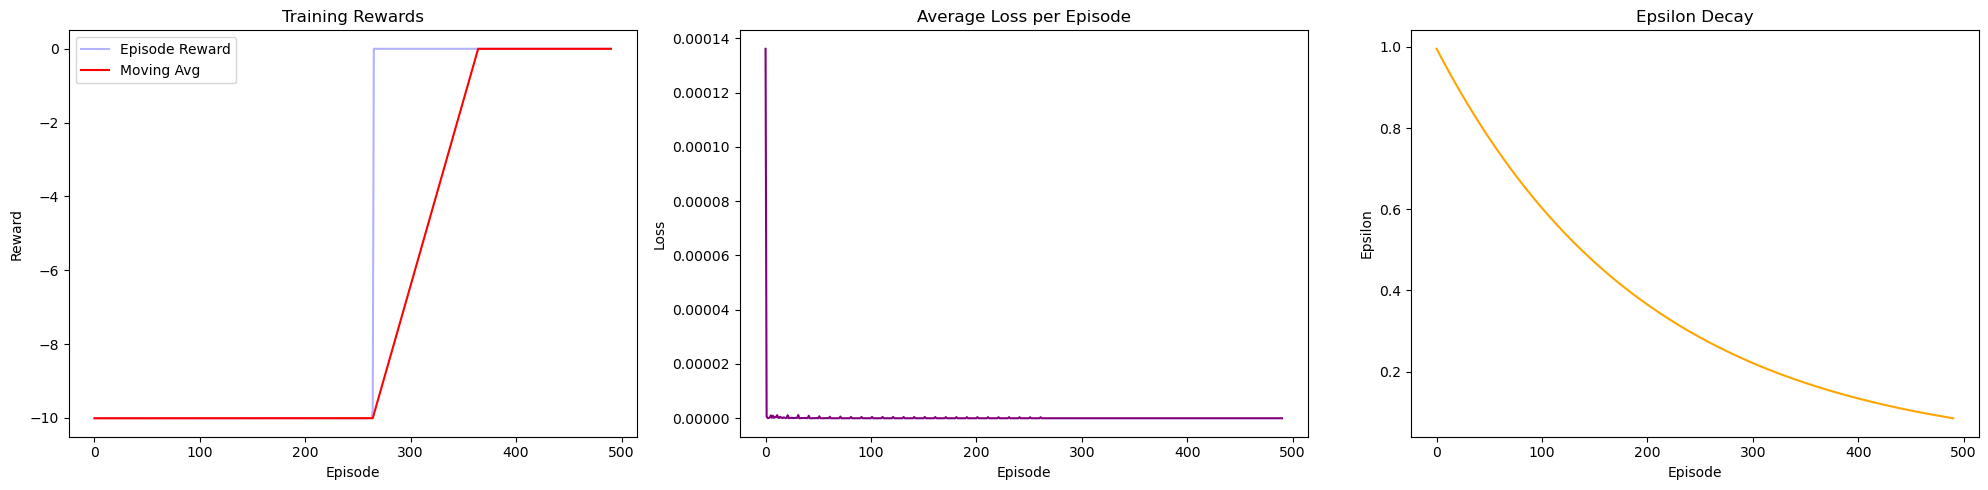

Episode 490/500 | Steps: 0 | Reward: 0.00 | Loss: 0.0000 | Epsilon: 0.09
Model saved to c:\Users\khory\Desktop\godot-dqn-agent\dqn-src\dqn_model.pth
Godot Headless terminated.
Godot disconnected.
WebSocket server stopped.


In [3]:
async def train():
    # Hyperparameters
    config = {
        "gamma": 0.99,
        "epsilon_start": 1.0,
        "epsilon_min": 0.01,
        "epsilon_decay": 0.995,
        "batch_size": 64,
        "learning_rate": 0.001,
        "buffer_size": 100000
    }

    state_size = 7
    action_size = 6
    agent = DQNAgent(state_size, action_size, config)
    env = GodotEnv()

    await env.start_server()

    # Launch Godot in Headless Mode
    godot_exe = os.path.expanduser(r"~\scoop\apps\godot\current\godot.console.exe")
    project_path = os.path.abspath(r"..\godot-src")
    print(f"Launching Godot Headless at: {project_path}")

    # Subprocess avoids blocking Jupyter
    godot_process = subprocess.Popen([godot_exe, "--headless", "--path", project_path])

    num_episodes = 500
    target_update_freq = 10

    episode_rewards = []
    moving_avg = []
    epsilons = []
    episode_losses = []
    episodes_run = 0

    try:
        # Wait for Godot to connect (raises RuntimeError on timeout)
        await wait_for_godot(env)

        for episode in range(num_episodes):
            state = await env.reset()
            total_reward = 0
            total_loss = 0
            done = False
            step_count = 0

            while not done and env.websocket is not None:
                action = agent.get_action(state)
                next_state, reward, done, score = await env.step(action)

                agent.memory.add(state, action, reward, next_state, done)
                loss = agent.train_step()

                state = next_state
                total_reward += reward
                total_loss += loss
                step_count += 1

                # Failsafe for getting stuck
                if step_count > 1000:
                    done = True

            episodes_run += 1
            agent.update_epsilon()
            if episode % target_update_freq == 0:
                agent.update_target_network()

            episode_rewards.append(total_reward)
            epsilons.append(agent.epsilon)
            episode_losses.append(total_loss / max(1, step_count))

            # Calculate moving average
            if len(episode_rewards) >= 100:
                moving_avg.append(np.mean(episode_rewards[-100:]))
            else:
                moving_avg.append(np.mean(episode_rewards))

            if episode % 10 == 0:
                plot_metrics(episode_rewards, moving_avg, epsilons, episode_losses)
                print(f"Episode {episode}/{num_episodes} | Steps: {step_count} | Reward: {total_reward:.2f} | Loss: {episode_losses[-1]:.4f} | Epsilon: {agent.epsilon:.2f}")

    except RuntimeError as e:
        print(f"Training aborted: {e}")
    except KeyboardInterrupt:
        print("Training interrupted manually.")
    finally:
        # Save the trained model weights
        import torch
        if episodes_run > 0:
            torch.save(agent.policy_net.state_dict(), MODEL_PATH)
            print(f"Model saved to {MODEL_PATH}")
        else:
            print("No episodes completed; skipping model save.")

        # Kill Godot headless process safely
        godot_process.terminate()
        print("Godot Headless terminated.")

        # Release the port so the cell can be re-run
        await env.stop_server()

await train()

## Phase 5: Evaluation & Visualization
Run this cell to evaluate the agent after training. The agent will act deterministically (Epsilon = 0).

In [4]:
async def test_agent():
    config = {
        "gamma": 0.99,
        "epsilon_start": 0.0, # NO EXPLORATION
        "epsilon_min": 0.0,
        "epsilon_decay": 1.0,
        "batch_size": 64,
        "learning_rate": 0.001,
        "buffer_size": 1000
    }

    agent = DQNAgent(7, 6, config)

    # Load trained weights if available
    import torch
    import os
    if os.path.exists(MODEL_PATH):
        agent.policy_net.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
        agent.policy_net.eval()
        print("Loaded trained weights.")
    else:
        print("Warning: No trained weights found. Agent will use random initialized weights.")

    env = GodotEnv()
    await env.start_server()

    godot_exe = os.path.expanduser(r"~\scoop\apps\godot\current\godot.console.exe")
    project_path = os.path.abspath(r"..\godot-src")
    godot_process = subprocess.Popen([godot_exe, "--headless", "--path", project_path])

    try:
        await wait_for_godot(env)

        test_episodes = 5
        for episode in range(test_episodes):
            state = await env.reset()
            total_reward = 0
            done = False
            step_count = 0

            while not done and env.websocket is not None:
                action = agent.get_action(state)
                next_state, reward, done, score = await env.step(action)
                state = next_state
                total_reward += reward
                step_count += 1
                if step_count > 1000:
                    break

            print(f"Test Episode {episode + 1} | Score: {score} | Total Reward: {total_reward:.2f} | Steps Survived: {step_count}")
    except RuntimeError as e:
        print(f"Evaluation aborted: {e}")
    finally:
        godot_process.terminate()
        print("Evaluation finished. Godot Headless terminated.")
        await env.stop_server()

await test_agent()

Loaded trained weights.
WebSocket server started at ws://127.0.0.1:11000
Godot connected!
Test Episode 1 | Score: 0.0 | Total Reward: -10.01 | Steps Survived: 1001
Test Episode 2 | Score: 0.0 | Total Reward: -10.01 | Steps Survived: 1001
Test Episode 3 | Score: 0.0 | Total Reward: -10.01 | Steps Survived: 1001
Test Episode 4 | Score: 0.0 | Total Reward: -10.01 | Steps Survived: 1001
Test Episode 5 | Score: 0.0 | Total Reward: -10.01 | Steps Survived: 1001
Evaluation finished. Godot Headless terminated.
Godot disconnected.
WebSocket server stopped.
